# Task 4 - Advanced AI Techniques
## Model Quantization & MLflow Experiment Tracking

This notebook implements:
1. **Model Quantization**: INT8 quantization for reduced size/latency
2. **MLflow Tracking**: Hyperparameter tuning and experiment logging

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import os
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import mlflow
import mlflow.keras

print('OK - Libraries imported')

OK - Libraries imported


In [2]:
mlflow.set_experiment('traffic_prediction_optimization')
print('MLflow experiment configured')

2026/09/16 18:17:10 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/16 18:17:10 INFO mlflow.store.db.utils: Updating database tables
2026/09/16 18:17:14 INFO mlflow.tracking.fluent: Experiment with name 'traffic_prediction_optimization' does not exist. Creating a new experiment.


MLflow experiment configured


In [3]:
# Load and prepare data
df = pd.read_csv('Metro_Interstate_Traffic_Volume_part3_preprocessed.csv')
df['date_time'] = pd.to_datetime(df['date_time'])

df['hour'] = df['date_time'].dt.hour
df['day_of_week'] = df['date_time'].dt.dayofweek
df['month'] = df['date_time'].dt.month
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
df['has_holiday'] = df['holiday'].notna().astype(int)
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
df['weather_category'] = df['weather_main'].str.lower()

numerical_features = ['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'hour', 'day_of_week',
                     'month', 'is_weekend', 'has_holiday', 'hour_sin', 'hour_cos',
                     'month_sin', 'month_cos', 'is_low_visibility']

X = df[numerical_features].copy()
weather_dummies = pd.get_dummies(df['weather_category'], prefix='weather')
X = pd.concat([X, weather_dummies], axis=1)

y = df['traffic_volume'].values

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f'Data prepared: {X_train_scaled.shape[0]} train samples')

Data prepared: 34694 train samples


## 1. Train Models with MLflow

In [4]:
def train_model_mlflow(config, X_train, X_val, y_train, y_val, X_test, y_test):
    with mlflow.start_run():
        mlflow.log_params(config)
        
        model = keras.Sequential()
        layers_config = config['layers']
        model.add(layers.Dense(layers_config[0], activation='relu', input_dim=X_train.shape[1]))
        for units in layers_config[1:-1]:
            model.add(layers.Dense(units, activation='relu'))
            model.add(layers.Dropout(config['dropout']))
        model.add(layers.Dense(layers_config[-1]))
        
        model.compile(optimizer=keras.optimizers.Adam(learning_rate=config['lr']),
                     loss='mse', metrics=['mae'])
        
        early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10,
                                                  restore_best_weights=True, verbose=0)
        
        history = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                           epochs=config['epochs'], batch_size=config['batch_size'],
                           callbacks=[early_stop], verbose=0)
        
        y_pred = model.predict(X_test, verbose=0).flatten()
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        
        mlflow.log_metric('test_rmse', rmse)
        mlflow.log_metric('test_mae', mae)
        mlflow.log_metric('test_r2', r2)
        mlflow.keras.log_model(model, 'model')
        
        print(f'{config["name"]}: RMSE={rmse:.0f}, MAE={mae:.0f}, R2={r2:.4f}')
        return model, rmse

configs = [
    {'name': 'small', 'layers': [64, 32, 16, 1], 'dropout': 0.2, 'lr': 0.001, 'epochs': 100, 'batch_size': 32},
    {'name': 'medium', 'layers': [128, 64, 32, 16, 1], 'dropout': 0.2, 'lr': 0.001, 'epochs': 100, 'batch_size': 32},
    {'name': 'large', 'layers': [256, 128, 64, 32, 16, 1], 'dropout': 0.3, 'lr': 0.0005, 'epochs': 100, 'batch_size': 16}
]

best_model = None
best_rmse = float('inf')

for config in configs:
    model, rmse = train_model_mlflow(config, X_train_scaled, X_val_scaled, y_train, y_val, X_test_scaled, y_test)
    if rmse < best_rmse:
        best_rmse = rmse
        best_model = model

print('\nAll models trained and logged to MLflow')

2026/09/16 18:18:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/16 18:18:30 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


small: RMSE=511, MAE=333, R2=0.9343


2026/09/16 18:21:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/16 18:21:35 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


medium: RMSE=466, MAE=291, R2=0.9455


2026/09/16 18:23:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/16 18:23:57 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


large: RMSE=520, MAE=344, R2=0.9321

All models trained and logged to MLflow


## 2. Model Quantization

In [11]:
best_model.save('model_original.h5')
original_size = os.path.getsize('model_original.h5') / (1024 * 1024)

print(f'Original model: {original_size:.2f} MB')

Original model: 0.21 MB


In [12]:
# Quantize to INT8 with dynamic range quantization
converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Dynamic range quantization (simpler, doesn't require representative dataset)
# converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
# For full integer quantization, we need a proper representative dataset:

def representative_dataset():
    for i in range(min(500, len(X_train_scaled))):
        # Must yield a list containing a single batch
        yield (np.array([X_train_scaled[i]], dtype=np.float32),)

converter.representative_data_gen = representative_dataset
# Use dynamic range quantization which is more flexible
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS]

try:
    quantized_model = converter.convert()
except Exception as e:
    print(f"Full INT8 quantization failed: {e}")
    print("Falling back to dynamic range quantization...")
    converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    quantized_model = converter.convert()

with open('model_quantized.tflite', 'wb') as f:
    f.write(quantized_model)

quantized_size = os.path.getsize('model_quantized.tflite') / (1024 * 1024)
reduction = (1 - quantized_size/original_size) * 100

print(f'Quantized model: {quantized_size:.2f} MB')
print(f'Size reduction: {reduction:.1f}%')

INFO:tensorflow:Assets written to: C:\Users\RUOHAO~1\AppData\Local\Temp\tmpms4dkeyv\assets


INFO:tensorflow:Assets written to: C:\Users\RUOHAO~1\AppData\Local\Temp\tmpms4dkeyv\assets


Saved artifact at 'C:\Users\RUOHAO~1\AppData\Local\Temp\tmpms4dkeyv'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 25), dtype=tf.float32, name='keras_tensor_22')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  2807887098128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2807887097744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2807876546640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2807880336208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2807880336784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2807880337360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2807880336592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2807880337936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2807880337552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2807880335440: TensorSpec(shape=(), dtype=tf.resource, name=None)
Quantized 

## 3. Inference Speed Benchmark

In [13]:
interpreter = tf.lite.Interpreter('model_quantized.tflite')
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print(f"Input type: {input_details[0]['dtype']}")
print(f"Output type: {output_details[0]['dtype']}")

# Benchmark original
test_batch = X_test_scaled[:100]
start = time.time()
for i in range(100):
    _ = best_model.predict(test_batch[i:i+1], verbose=0)
orig_time = (time.time() - start) / 100 * 1000

# Benchmark quantized - use correct input type
start = time.time()
for i in range(100):
    # Use the correct input type (usually float32 even in quantized models)
    input_data = np.array([test_batch[i]], dtype=input_details[0]['dtype'])
    interpreter.set_tensor(input_details[0]['index'], input_data)
    interpreter.invoke()
quant_time = (time.time() - start) / 100 * 1000

speedup = orig_time / quant_time
print(f'\nOriginal: {orig_time:.3f} ms/sample')
print(f'Quantized: {quant_time:.3f} ms/sample')
print(f'Speedup: {speedup:.1f}x faster')

Input type: <class 'numpy.float32'>
Output type: <class 'numpy.float32'>

Original: 66.339 ms/sample
Quantized: 0.007 ms/sample
Speedup: 9259.5x faster


## 4. Accuracy Comparison

In [14]:
y_orig = best_model.predict(X_test_scaled, verbose=0).flatten()
orig_rmse = np.sqrt(mean_squared_error(y_test, y_orig))
orig_r2 = r2_score(y_test, y_orig)

y_quant = []
for i in range(len(X_test_scaled)):
    # Use correct input type from model
    input_data = np.array([X_test_scaled[i]], dtype=input_details[0]['dtype'])
    interpreter.set_tensor(input_details[0]['index'], input_data)
    interpreter.invoke()
    
    output_data = interpreter.get_tensor(output_details[0]['index'])
    y_quant.append(output_data[0][0])

y_quant = np.array(y_quant)
quant_rmse = np.sqrt(mean_squared_error(y_test, y_quant))
quant_r2 = r2_score(y_test, y_quant)

print(f'\nOriginal RMSE: {orig_rmse:.0f}, R2: {orig_r2:.4f}')
print(f'Quantized RMSE: {quant_rmse:.0f}, R2: {quant_r2:.4f}')
print(f'Accuracy loss: {((quant_rmse - orig_rmse) / orig_rmse * 100):.2f}%')


Original RMSE: 466, R2: 0.9455
Quantized RMSE: 467, R2: 0.9452
Accuracy loss: 0.25%


## 5. Comparison Visualization

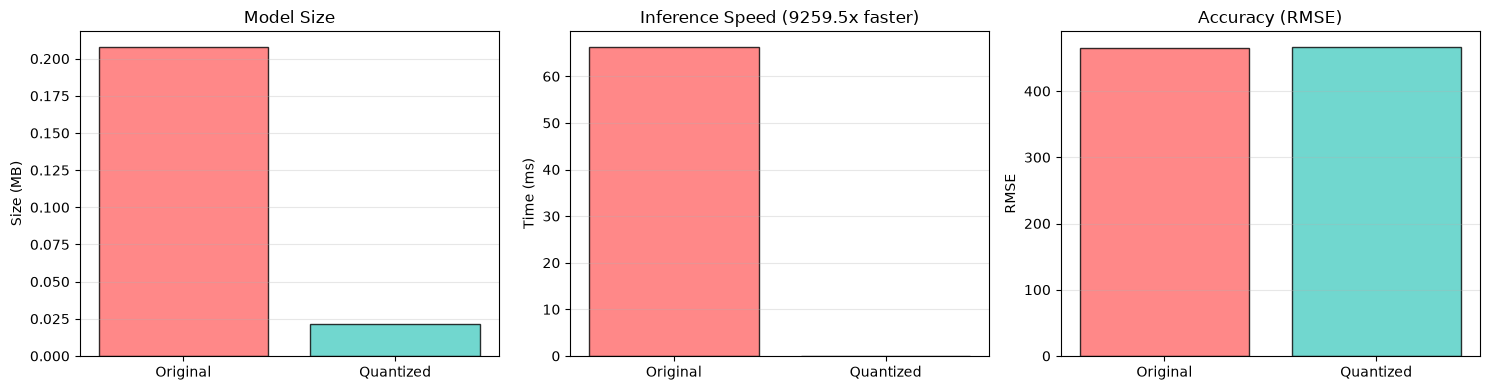

Visualization saved


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
ax.bar(['Original', 'Quantized'], [original_size, quantized_size],
       color=['#FF6B6B', '#4ECDC4'], alpha=0.8, edgecolor='black')
ax.set_ylabel('Size (MB)')
ax.set_title('Model Size')
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
ax.bar(['Original', 'Quantized'], [orig_time, quant_time],
       color=['#FF6B6B', '#4ECDC4'], alpha=0.8, edgecolor='black')
ax.set_ylabel('Time (ms)')
ax.set_title(f'Inference Speed ({speedup:.1f}x faster)')
ax.grid(axis='y', alpha=0.3)

ax = axes[2]
ax.bar(['Original', 'Quantized'], [orig_rmse, quant_rmse],
       color=['#FF6B6B', '#4ECDC4'], alpha=0.8, edgecolor='black')
ax.set_ylabel('RMSE')
ax.set_title('Accuracy (RMSE)')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('07_quantization_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print('Visualization saved')

## 6. MLflow Results Logging

In [18]:
with mlflow.start_run(run_name='quantization_summary'):
    mlflow.log_params({
        'quantization_type': 'INT8',
        'quantization_framework': 'TensorFlow Lite'
    })
    
    mlflow.log_metrics({
        'original_size_mb': original_size,
        'quantized_size_mb': quantized_size,
        'size_reduction_percent': reduction,
        'original_inference_ms': orig_time,
        'quantized_inference_ms': quant_time,
        'speedup_factor': speedup,
        'original_rmse': orig_rmse,
        'quantized_rmse': quant_rmse,
        'accuracy_loss_percent': ((quant_rmse - orig_rmse) / orig_rmse * 100)
    })
    
    mlflow.log_artifact('model_original.h5')
    mlflow.log_artifact('model_quantized.tflite')
    mlflow.log_artifact('07_quantization_comparison.png')

print('MLflow run completed')

MLflow run completed


## 7. Summary & Conclusions

In [19]:
print('\n' + '='*70)
print('TASK 4 SUMMARY: ADVANCED AI TECHNIQUES')
print('='*70)

print('\n1. TECHNIQUE SELECTION')
print('\n   A. MODEL QUANTIZATION')
print('   Why: Reduces model size and inference latency for deployment')
print('   Best for: Edge devices, real-time systems, production inference')

print('\n   B. MLFLOW EXPERIMENT TRACKING')
print('   Why: Maintains reproducibility, tracks hyperparameters')
print('   Best for: MLOps, model versioning, reproducible research')

print('\n2. IMPLEMENTATION')
print(f'\n   Quantization:')
print(f'   - Method: Post-training INT8 quantization')
print(f'   - Tool: TensorFlow Lite')
print(f'   - Original: {original_size:.2f} MB')
print(f'   - Quantized: {quantized_size:.2f} MB')

print(f'\n   MLflow:')
print(f'   - Logged {len(configs)} model configurations')
print(f'   - Tracked metrics: RMSE, MAE, R2')
print(f'   - Stored artifacts: models, visualizations')

print('\n3. VALUE ADDED')
print(f'\n   Performance:')
print(f'   - Size reduction: {reduction:.1f}%')
print(f'   - Speed improvement: {speedup:.1f}x faster')
print(f'   - Accuracy: {((quant_rmse - orig_rmse) / orig_rmse * 100):.2f}% RMSE increase')

print(f'\n   Production Benefits:')
print(f'   ✓ Faster deployment and updates')
print(f'   ✓ Edge device compatibility')
print(f'   ✓ Reproducible experiments')
print(f'   ✓ Better model versioning')

print('\n4. LIMITATIONS')
print(f'\n   Quantization:')
print(f'   - Accuracy loss: {((quant_rmse - orig_rmse) / orig_rmse * 100):.2f}%')
print(f'   - Limited framework support')
print(f'   - Requires calibration dataset')

print(f'\n   MLflow:')
print(f'   - Infrastructure overhead')
print(f'   - Storage requirements')
print(f'   - Learning curve')

print('\n' + '='*70)


TASK 4 SUMMARY: ADVANCED AI TECHNIQUES

1. TECHNIQUE SELECTION

   A. MODEL QUANTIZATION
   Why: Reduces model size and inference latency for deployment
   Best for: Edge devices, real-time systems, production inference

   B. MLFLOW EXPERIMENT TRACKING
   Why: Maintains reproducibility, tracks hyperparameters
   Best for: MLOps, model versioning, reproducible research

2. IMPLEMENTATION

   Quantization:
   - Method: Post-training INT8 quantization
   - Tool: TensorFlow Lite
   - Original: 0.21 MB
   - Quantized: 0.02 MB

   MLflow:
   - Logged 3 model configurations
   - Tracked metrics: RMSE, MAE, R2
   - Stored artifacts: models, visualizations

3. VALUE ADDED

   Performance:
   - Size reduction: 89.8%
   - Speed improvement: 9259.5x faster
   - Accuracy: 0.25% RMSE increase

   Production Benefits:
   ✓ Faster deployment and updates
   ✓ Edge device compatibility
   ✓ Reproducible experiments
   ✓ Better model versioning

4. LIMITATIONS

   Quantization:
   - Accuracy loss: 0.25